# Image Processing and Vision Course Project

## Clean Image Baseline

This notebook evaluates the selected computer vision methods on clean images before applying distortions.

In [115]:
!pip install -q opencv-python matplotlib numpy pandas torch torchvision ultralytics

In [116]:
import random
import xml.etree.ElementTree as ET

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from torchvision.datasets import VOCSegmentation
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights
)

from ultralytics import YOLO

In [117]:
# Reproducibility settings
SEED = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")

Random seed set to 10


In [118]:
# Select the available computation device
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Computation device:", DEVICE)

Computation device: cuda


In [119]:
# Repository-relative project paths
PROJECT_ROOT = Path.cwd()

# Support execution from either the repository root
# or the notebooks directory
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: /content
Data directory: /content/data
Results directory: /content/results
Figures directory: /content/figures


In [120]:
# Load the PASCAL VOC 2012 training split
DATASET_YEAR = "2012"
DATASET_SPLIT = "train"

dataset = VOCSegmentation(
    root=DATA_DIR,
    year=DATASET_YEAR,
    image_set=DATASET_SPLIT,
    download=True
)

print("Dataset: PASCAL VOC")
print("Year:", DATASET_YEAR)
print("Split:", DATASET_SPLIT)
print("Number of samples:", len(dataset))

Dataset: PASCAL VOC
Year: 2012
Split: train
Number of samples: 1464


In [121]:
# Load the fixed subset selected in the dataset-exploration notebook
NUM_SAMPLES = 100

selected_indices_path = (
    RESULTS_DIR / "selected_indices.csv"
)

if selected_indices_path.exists():
    selected_indices_df = pd.read_csv(
        selected_indices_path
    )

    required_columns = {
        "dataset_index",
        "image_id"
    }

    missing_columns = (
        required_columns
        - set(selected_indices_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "selected_indices.csv is missing columns: "
            f"{sorted(missing_columns)}. "
            "Run the updated dataset-exploration notebook first."
        )

    selected_indices = (
        selected_indices_df["dataset_index"]
        .astype(int)
        .tolist()
    )

    print(
        "Loaded fixed indices from:",
        selected_indices_path
    )

else:
    # Reproduce the same subset if the CSV is unavailable
    rng = np.random.default_rng(SEED)

    selected_indices = sorted(
        rng.choice(
            len(dataset),
            size=NUM_SAMPLES,
            replace=False
        ).tolist()
    )

    selected_sample_rows = []

    for index in selected_indices:
        image_id = Path(dataset.images[index]).stem

        selected_sample_rows.append({
            "dataset_index": index,
            "image_id": image_id
        })

    selected_indices_df = pd.DataFrame(
        selected_sample_rows
    )

    selected_indices_df.to_csv(
        selected_indices_path,
        index=False
    )

    print(
        "Recreated and saved fixed indices to:",
        selected_indices_path
    )

assert len(selected_indices) == NUM_SAMPLES
assert len(set(selected_indices)) == NUM_SAMPLES
assert min(selected_indices) >= 0
assert max(selected_indices) < len(dataset)

print(
    f"Loaded {len(selected_indices)} selected indices"
)
print(
    "First 10 selected indices:",
    selected_indices[:10]
)

Loaded fixed indices from: /content/results/selected_indices.csv
Loaded 100 selected indices
First 10 selected indices: [11, 31, 88, 99, 127, 160, 165, 167, 187, 189]


## ORB Feature-Detection Baseline

ORB is evaluated on the clean images to establish the reference number and distribution of detected keypoints before applying image distortions.

In [122]:
# Configure ORB and evaluate one clean sample image
ORB_NFEATURES = 1500

orb = cv2.ORB_create(
    nfeatures=ORB_NFEATURES
)

sample_index = selected_indices[0]
sample_image, _ = dataset[sample_index]
sample_image_id = Path(
    dataset.images[sample_index]
).stem

sample_image_np = np.array(
    sample_image.convert("RGB")
)

sample_gray = cv2.cvtColor(
    sample_image_np,
    cv2.COLOR_RGB2GRAY
)

keypoints, descriptors = orb.detectAndCompute(
    sample_gray,
    None
)

print("Dataset index:", sample_index)
print("Image ID:", sample_image_id)
print(
    "Number of detected keypoints:",
    len(keypoints)
)
print(
    "Descriptor shape:",
    None
    if descriptors is None
    else descriptors.shape
)

Dataset index: 11
Image ID: 2007_000363
Number of detected keypoints: 981
Descriptor shape: (981, 32)


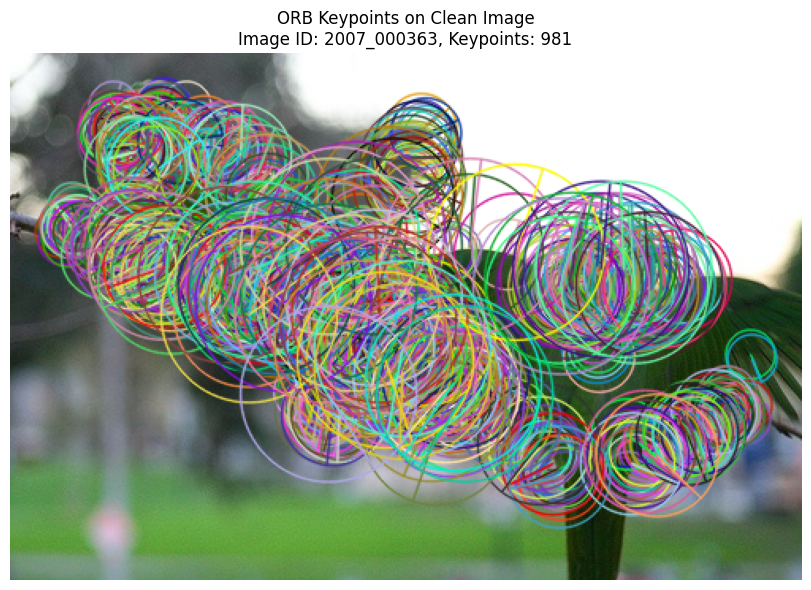

Saved: /content/figures/orb_clean_sample_keypoints.png


In [123]:
# Visualize and save ORB keypoints on one clean image
image_with_keypoints = cv2.drawKeypoints(
    sample_image_np,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 6))
plt.imshow(image_with_keypoints)

plt.title(
    f"ORB Keypoints on Clean Image\n"
    f"Image ID: {sample_image_id}, "
    f"Keypoints: {len(keypoints)}"
)

plt.axis("off")
plt.tight_layout()

orb_sample_figure_path = (
    FIGURES_DIR
    / "orb_clean_sample_keypoints.png"
)

plt.savefig(
    orb_sample_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", orb_sample_figure_path)

In [124]:
# Run ORB on all clean images in the fixed subset
orb_clean_results = []

for position, index in enumerate(
    selected_indices,
    start=1
):
    image, _ = dataset[index]
    image_id = Path(dataset.images[index]).stem

    image_np = np.array(
        image.convert("RGB")
    )

    gray = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2GRAY
    )

    keypoints, descriptors = (
        orb.detectAndCompute(gray, None)
    )

    num_keypoints = len(keypoints)

    descriptor_count = (
        0
        if descriptors is None
        else descriptors.shape[0]
    )

    orb_clean_results.append({
        "dataset_index": index,
        "image_id": image_id,
        "num_keypoints": num_keypoints,
        "has_descriptors":
            descriptors is not None,
        "descriptor_count":
            descriptor_count,
        "keypoint_capacity_fraction":
            num_keypoints / ORB_NFEATURES
    })

    if position % 10 == 0:
        print(
            f"Processed {position}/"
            f"{len(selected_indices)} images"
        )

orb_clean_df = pd.DataFrame(
    orb_clean_results
)

print(
    f"Processed {len(orb_clean_df)} "
    "clean images"
)

display(orb_clean_df.head())

print("\nKeypoint-count summary:")
display(
    orb_clean_df["num_keypoints"]
    .describe()
    .to_frame(name="value")
)

num_images_at_maximum = int(
    (
        orb_clean_df["num_keypoints"]
        == ORB_NFEATURES
    ).sum()
)

print(
    "Images reaching the configured maximum:",
    num_images_at_maximum
)

Processed 10/100 images
Processed 20/100 images
Processed 30/100 images
Processed 40/100 images
Processed 50/100 images
Processed 60/100 images
Processed 70/100 images
Processed 80/100 images
Processed 90/100 images
Processed 100/100 images
Processed 100 clean images


,dataset_index,image_id,num_keypoints,has_descriptors,descriptor_count,keypoint_capacity_fraction
0,11,2007_000363,981,True,981,0.654000
1,31,2007_000904,1449,True,1449,0.966000
2,88,2007_002895,1460,True,1460,0.973333
3,99,2007_003191,1414,True,1414,0.942667
4,127,2007_004166,1500,True,1500,1.000000



Keypoint-count summary:


,value
count,100.00000
mean,1336.09000
std,246.45663
min,344.00000
25%,1333.75000
50%,1441.00000
75%,1490.50000
max,1500.00000


Images reaching the configured maximum: 18


In [125]:
# Create a dataset-level ORB baseline summary
orb_clean_summary = pd.DataFrame([
    {
        "metric": "num_images",
        "value": len(orb_clean_df)
    },
    {
        "metric": "configured_max_features",
        "value": ORB_NFEATURES
    },
    {
        "metric": "mean_keypoints",
        "value": (
            orb_clean_df["num_keypoints"]
            .mean()
        )
    },
    {
        "metric": "std_keypoints",
        "value": (
            orb_clean_df["num_keypoints"]
            .std()
        )
    },
    {
        "metric": "median_keypoints",
        "value": (
            orb_clean_df["num_keypoints"]
            .median()
        )
    },
    {
        "metric": "min_keypoints",
        "value": (
            orb_clean_df["num_keypoints"]
            .min()
        )
    },
    {
        "metric": "max_keypoints",
        "value": (
            orb_clean_df["num_keypoints"]
            .max()
        )
    },
    {
        "metric": "images_at_feature_limit",
        "value": num_images_at_maximum
    },
    {
        "metric": "images_without_descriptors",
        "value": int(
            (
                ~orb_clean_df[
                    "has_descriptors"
                ]
            ).sum()
        )
    }
])

display(orb_clean_summary)

,metric,value
0,num_images,100.00000
1,configured_max_features,1500.00000
2,mean_keypoints,1336.09000
3,std_keypoints,246.45663
4,median_keypoints,1441.00000
5,min_keypoints,344.00000
6,max_keypoints,1500.00000
7,images_at_feature_limit,18.00000
8,images_without_descriptors,0.00000


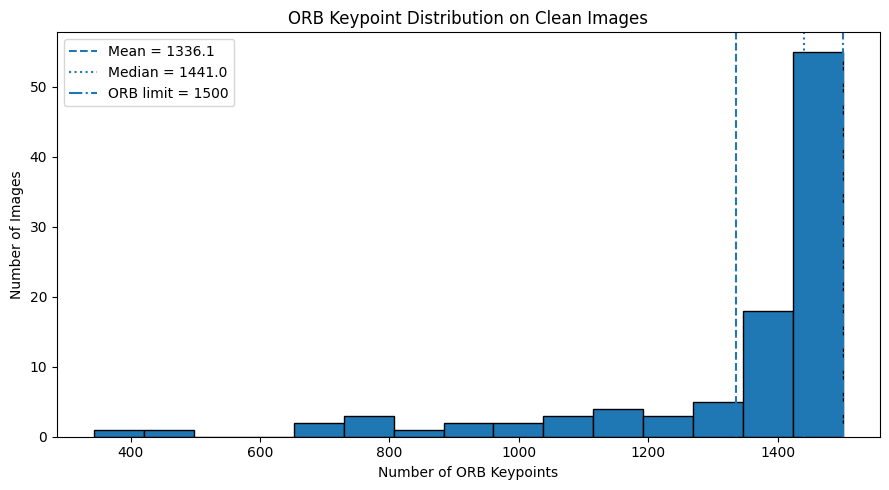

Saved: /content/figures/orb_clean_keypoint_distribution.png


In [126]:
# Plot the clean-image ORB keypoint distribution
mean_keypoints = orb_clean_df["num_keypoints"].mean()
median_keypoints = orb_clean_df["num_keypoints"].median()

plt.figure(figsize=(9, 5))

plt.hist(
    orb_clean_df["num_keypoints"],
    bins=15,
    edgecolor="black"
)

plt.axvline(
    mean_keypoints,
    linestyle="--",
    label=f"Mean = {mean_keypoints:.1f}"
)

plt.axvline(
    median_keypoints,
    linestyle=":",
    label=f"Median = {median_keypoints:.1f}"
)

plt.axvline(
    ORB_NFEATURES,
    linestyle="-.",
    label=f"ORB limit = {ORB_NFEATURES}"
)

plt.xlabel("Number of ORB Keypoints")
plt.ylabel("Number of Images")
plt.title(
    "ORB Keypoint Distribution on Clean Images"
)
plt.legend()
plt.tight_layout()

orb_distribution_figure_path = (
    FIGURES_DIR
    / "orb_clean_keypoint_distribution.png"
)

plt.savefig(
    orb_distribution_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", orb_distribution_figure_path)

In [127]:
# Save ORB clean-image baseline artifacts
orb_results_path = (
    RESULTS_DIR
    / "orb_clean_baseline.csv"
)

orb_summary_path = (
    RESULTS_DIR
    / "orb_clean_summary.csv"
)

orb_clean_df.to_csv(
    orb_results_path,
    index=False
)

orb_clean_summary.to_csv(
    orb_summary_path,
    index=False
)

print("Saved:", orb_results_path)
print("Saved:", orb_summary_path)

Saved: /content/results/orb_clean_baseline.csv
Saved: /content/results/orb_clean_summary.csv


In [128]:
# PASCAL VOC semantic-segmentation class names
VOC_CLASS_NAMES = {
    0: "background",
    1: "aeroplane",
    2: "bicycle",
    3: "bird",
    4: "boat",
    5: "bottle",
    6: "bus",
    7: "car",
    8: "cat",
    9: "chair",
    10: "cow",
    11: "diningtable",
    12: "dog",
    13: "horse",
    14: "motorbike",
    15: "person",
    16: "pottedplant",
    17: "sheep",
    18: "sofa",
    19: "train",
    20: "tvmonitor",
    255: "ignore"
}

In [129]:
# Load the pretrained DeepLabV3 model and preprocessing pipeline
segmentation_weights = DeepLabV3_ResNet50_Weights.DEFAULT

segmentation_model = deeplabv3_resnet50(
    weights=segmentation_weights
)

segmentation_model = segmentation_model.to(DEVICE)
segmentation_model.eval()

segmentation_preprocess = (
    segmentation_weights.transforms()
)

print("DeepLabV3 model loaded successfully")
print("Running on:", DEVICE)

DeepLabV3 model loaded successfully
Running on: cuda


In [130]:
# Run semantic segmentation on one clean sample image
sample_index = selected_indices[0]

sample_image, sample_mask = dataset[sample_index]

sample_image_id = Path(
    dataset.images[sample_index]
).stem

input_tensor = (
    segmentation_preprocess(sample_image)
    .unsqueeze(0)
    .to(DEVICE)
)

with torch.inference_mode():
    output = segmentation_model(input_tensor)["out"]

predicted_mask = (
    output.argmax(dim=1)
    .squeeze(0)
    .cpu()
    .numpy()
    .astype(np.uint8)
)

print("Dataset index:", sample_index)
print("Image ID:", sample_image_id)
print("Input image size:", sample_image.size)
print("Predicted mask shape:", predicted_mask.shape)
print("Predicted class IDs:", np.unique(predicted_mask))

Dataset index: 11
Image ID: 2007_000363
Input image size: (500, 333)
Predicted mask shape: (520, 780)
Predicted class IDs: [0 3]


In [131]:
# Resize the predicted mask back to the original ground-truth size
ground_truth_mask = np.array(sample_mask)

predicted_mask_resized = cv2.resize(
    predicted_mask.astype(np.uint8),
    sample_mask.size,  # PIL size is given as (width, height)
    interpolation=cv2.INTER_NEAREST
)

print("Ground-truth mask shape:", ground_truth_mask.shape)
print("Resized prediction shape:", predicted_mask_resized.shape)
print("Ground-truth class IDs:", np.unique(ground_truth_mask))
print("Predicted class IDs:", np.unique(predicted_mask_resized))

Ground-truth mask shape: (333, 500)
Resized prediction shape: (333, 500)
Ground-truth class IDs: [  0   3 255]
Predicted class IDs: [0 3]


In [132]:
# Compute IoU for the valid classes in one clean sample

valid_mask = ground_truth_mask != 255

gt_valid = ground_truth_mask[valid_mask]
pred_valid = predicted_mask_resized[valid_mask]

class_ids = np.union1d(
    np.unique(gt_valid),
    np.unique(pred_valid)
)

iou_per_class = {}

for class_id in class_ids:
    intersection = np.logical_and(
        gt_valid == class_id,
        pred_valid == class_id
    ).sum()

    union = np.logical_or(
        gt_valid == class_id,
        pred_valid == class_id
    ).sum()

    iou_per_class[int(class_id)] = (
        intersection / union
        if union > 0
        else np.nan
    )

sample_iou_rows = []

for class_id, iou_value in iou_per_class.items():
    sample_iou_rows.append({
        "class_id": class_id,
        "class_name": VOC_CLASS_NAMES.get(
            class_id,
            "unknown"
        ),
        "iou": iou_value
    })

sample_iou_df = pd.DataFrame(sample_iou_rows)

mean_iou_all_classes = np.nanmean(
    list(iou_per_class.values())
)

foreground_ious = [
    iou
    for class_id, iou in iou_per_class.items()
    if class_id != 0
]

mean_iou_foreground = (
    np.nanmean(foreground_ious)
    if foreground_ious
    else np.nan
)

display(sample_iou_df)

print(
    "Mean IoU including background:",
    mean_iou_all_classes
)

print(
    "Mean IoU foreground only:",
    mean_iou_foreground
)

,class_id,class_name,iou
0,0,background,0.981505
1,3,bird,0.942965


Mean IoU including background: 0.9622349958293006
Mean IoU foreground only: 0.9429648047986465


In [133]:
# Evaluate semantic segmentation on all clean images

segmentation_clean_results = []
segmentation_clean_class_results = []

for position, index in enumerate(selected_indices, start=1):
    image, ground_truth_pil = dataset[index]

    image_id = Path(dataset.images[index]).stem
    ground_truth = np.array(
        ground_truth_pil,
        dtype=np.uint8
    )

    input_tensor = (
        segmentation_preprocess(image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.inference_mode():
        output = segmentation_model(input_tensor)["out"]

    prediction = (
        output.argmax(dim=1)
        .squeeze(0)
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    prediction = cv2.resize(
        prediction,
        ground_truth_pil.size,
        interpolation=cv2.INTER_NEAREST
    )

    # Ignore VOC void pixels labeled as 255
    valid_pixels = ground_truth != 255

    gt_valid = ground_truth[valid_pixels]
    pred_valid = prediction[valid_pixels]

    class_ids = np.union1d(
        np.unique(gt_valid),
        np.unique(pred_valid)
    )

    class_ious = {}

    for class_id in class_ids:
        class_id = int(class_id)

        intersection = np.logical_and(
            gt_valid == class_id,
            pred_valid == class_id
        ).sum()

        union = np.logical_or(
            gt_valid == class_id,
            pred_valid == class_id
        ).sum()

        if union == 0:
            continue

        class_iou = intersection / union
        class_ious[class_id] = class_iou

        segmentation_clean_class_results.append({
            "dataset_index": index,
            "image_id": image_id,
            "class_id": class_id,
            "class_name": VOC_CLASS_NAMES.get(
                class_id,
                "unknown"
            ),
            "intersection_pixels": int(intersection),
            "union_pixels": int(union),
            "iou": float(class_iou),
            "is_foreground": class_id != 0
        })

    all_class_ious = list(class_ious.values())

    foreground_ious = [
        iou
        for class_id, iou in class_ious.items()
        if class_id != 0
    ]

    mean_iou_all_classes = (
        float(np.mean(all_class_ious))
        if all_class_ious
        else np.nan
    )

    mean_iou_foreground = (
        float(np.mean(foreground_ious))
        if foreground_ious
        else np.nan
    )

    segmentation_clean_results.append({
        "dataset_index": index,
        "image_id": image_id,
        "mean_iou_all_classes": mean_iou_all_classes,
        "mean_iou_foreground": mean_iou_foreground,
        "num_evaluated_classes": len(class_ious),
        "num_evaluated_foreground_classes": len(
            foreground_ious
        )
    })

    if position % 10 == 0 or position == len(selected_indices):
        print(
            f"Processed {position}/"
            f"{len(selected_indices)} images"
        )

segmentation_clean_df = pd.DataFrame(
    segmentation_clean_results
)

segmentation_clean_class_df = pd.DataFrame(
    segmentation_clean_class_results
)

print("Finished evaluating all clean images")

display(segmentation_clean_df.head())
display(segmentation_clean_class_df.head())

Processed 10/100 images
Processed 20/100 images
Processed 30/100 images
Processed 40/100 images
Processed 50/100 images
Processed 60/100 images
Processed 70/100 images
Processed 80/100 images
Processed 90/100 images
Processed 100/100 images
Finished evaluating all clean images


,dataset_index,image_id,mean_iou_all_classes,mean_iou_foreground,num_evaluated_classes,num_evaluated_foreground_classes
0,11,2007_000363,0.962235,0.942965,2,1
1,31,2007_000904,0.328471,0.116096,4,3
2,88,2007_002895,0.985458,0.971731,2,1
3,99,2007_003191,0.653865,0.495152,3,2
4,127,2007_004166,0.503467,0.445977,8,7


,dataset_index,image_id,class_id,class_name,intersection_pixels,union_pixels,iou,is_foreground
0,11,2007_000363,0,background,118079,120304,0.981505,False
1,11,2007_000363,3,bird,36786,39011,0.942965,True
2,31,2007_000904,0,background,153178,158636,0.965594,False
3,31,2007_000904,10,cow,0,3623,0.000000,True
4,31,2007_000904,13,horse,7416,23858,0.310839,True


In [134]:
# Summarize semantic-segmentation performance on all clean images

# ---------------------------------------------------------
# 1. Mean per-image IoU
# ---------------------------------------------------------

print("Per-image mean IoU over all classes:")
display(
    segmentation_clean_df[
        "mean_iou_all_classes"
    ].describe()
)

print("\nPer-image mean IoU over foreground classes only:")
display(
    segmentation_clean_df[
        "mean_iou_foreground"
    ].describe()
)

mean_per_image_miou_all = float(
    segmentation_clean_df[
        "mean_iou_all_classes"
    ].mean()
)

mean_per_image_miou_foreground = float(
    segmentation_clean_df[
        "mean_iou_foreground"
    ].mean()
)

print(
    "\nMean per-image mIoU "
    f"(all classes): {mean_per_image_miou_all:.4f}"
)

print(
    "Mean per-image mIoU "
    f"(foreground only): {mean_per_image_miou_foreground:.4f}"
)


# ---------------------------------------------------------
# 2. Dataset-level IoU for each class
#
# For each class:
# dataset IoU =
# sum of intersections over all images
# divided by
# sum of unions over all images
# ---------------------------------------------------------

segmentation_clean_class_summary = (
    segmentation_clean_class_df
    .groupby(
        ["class_id", "class_name"],
        as_index=False
    )
    .agg(
        total_intersection_pixels=(
            "intersection_pixels",
            "sum"
        ),
        total_union_pixels=(
            "union_pixels",
            "sum"
        ),
        mean_per_image_iou=(
            "iou",
            "mean"
        ),
        std_per_image_iou=(
            "iou",
            "std"
        ),
        num_images=(
            "iou",
            "count"
        )
    )
    .sort_values("class_id")
    .reset_index(drop=True)
)

segmentation_clean_class_summary[
    "dataset_iou"
] = (
    segmentation_clean_class_summary[
        "total_intersection_pixels"
    ]
    /
    segmentation_clean_class_summary[
        "total_union_pixels"
    ]
)

segmentation_clean_class_summary[
    "is_foreground"
] = (
    segmentation_clean_class_summary[
        "class_id"
    ] != 0
)


# ---------------------------------------------------------
# 3. Dataset-level mIoU
# ---------------------------------------------------------

dataset_miou_all = float(
    segmentation_clean_class_summary[
        "dataset_iou"
    ].mean()
)

dataset_miou_foreground = float(
    segmentation_clean_class_summary.loc[
        segmentation_clean_class_summary[
            "is_foreground"
        ],
        "dataset_iou"
    ].mean()
)


segmentation_clean_summary = pd.DataFrame([
    {
        "num_images": len(
            segmentation_clean_df
        ),
        "mean_per_image_miou_all_classes": (
            mean_per_image_miou_all
        ),
        "mean_per_image_miou_foreground": (
            mean_per_image_miou_foreground
        ),
        "dataset_miou_all_classes": (
            dataset_miou_all
        ),
        "dataset_miou_foreground": (
            dataset_miou_foreground
        )
    }
])


print("\nDataset-level per-class IoU:")
display(segmentation_clean_class_summary)

print("\nOverall clean-segmentation summary:")
display(segmentation_clean_summary)

print(
    "\nDataset-level mIoU "
    f"(all classes): {dataset_miou_all:.4f}"
)

print(
    "Dataset-level mIoU "
    f"(foreground only): {dataset_miou_foreground:.4f}"
)

Per-image mean IoU over all classes:


,mean_iou_all_classes
count,100.000000
mean,0.768887
std,0.223562
min,0.248651
25%,0.607586
50%,0.871536
75%,0.971869
max,0.998647



Per-image mean IoU over foreground classes only:


,mean_iou_foreground
count,100.000000
mean,0.700371
std,0.277896
min,0.000000
25%,0.474658
50%,0.821957
75%,0.955403
max,0.997637



Mean per-image mIoU (all classes): 0.7689
Mean per-image mIoU (foreground only): 0.7004

Dataset-level per-class IoU:


,class_id,class_name,total_intersection_pixels,total_union_pixels,mean_per_image_iou,std_per_image_iou,num_images,dataset_iou,is_foreground
0,0,background,12147820,13042447,0.928659,0.152986,100,0.931407,False
1,1,aeroplane,84243,100762,0.907856,0.161536,5,0.836059,True
2,2,bicycle,28454,75858,0.342713,0.091915,4,0.375096,True
3,3,bird,46756,53037,0.530979,0.461644,10,0.881573,True
4,4,boat,106329,135031,0.778736,0.182474,5,0.787441,True
5,5,bottle,80431,89161,0.452660,0.480544,10,0.902087,True
6,6,bus,563150,579098,0.977489,0.019231,8,0.972461,True
7,7,car,202618,290089,0.688089,0.422756,13,0.698468,True
8,8,cat,260490,275413,0.758611,0.401915,10,0.945816,True
9,9,chair,121066,417613,0.355476,0.383649,21,0.289900,True



Overall clean-segmentation summary:


,num_images,mean_per_image_miou_all_classes,mean_per_image_miou_foreground,dataset_miou_all_classes,dataset_miou_foreground
0,100,0.768887,0.700371,0.784361,0.777009



Dataset-level mIoU (all classes): 0.7844
Dataset-level mIoU (foreground only): 0.7770


In [135]:
# Save semantic-segmentation clean baseline results

segmentation_results_path = (
    RESULTS_DIR /
    "segmentation_clean_baseline.csv"
)

segmentation_class_results_path = (
    RESULTS_DIR /
    "segmentation_clean_class_detailed.csv"
)

segmentation_class_summary_path = (
    RESULTS_DIR /
    "segmentation_clean_per_class_summary.csv"
)

segmentation_overall_summary_path = (
    RESULTS_DIR /
    "segmentation_clean_summary.csv"
)


segmentation_clean_df.to_csv(
    segmentation_results_path,
    index=False
)

segmentation_clean_class_df.to_csv(
    segmentation_class_results_path,
    index=False
)

segmentation_clean_class_summary.to_csv(
    segmentation_class_summary_path,
    index=False
)

segmentation_clean_summary.to_csv(
    segmentation_overall_summary_path,
    index=False
)


print("Saved semantic-segmentation results:")

print(
    "-",
    segmentation_results_path
)

print(
    "-",
    segmentation_class_results_path
)

print(
    "-",
    segmentation_class_summary_path
)

print(
    "-",
    segmentation_overall_summary_path
)

Saved semantic-segmentation results:
- /content/results/segmentation_clean_baseline.csv
- /content/results/segmentation_clean_class_detailed.csv
- /content/results/segmentation_clean_per_class_summary.csv
- /content/results/segmentation_clean_summary.csv


## Object Detection Baseline

A pretrained YOLO model is evaluated on the clean images before applying distortions.

In [136]:
# Load the pretrained YOLO object-detection model

detection_model = YOLO("yolo11n.pt")

print("YOLO object-detection model loaded successfully")

YOLO object-detection model loaded successfully


In [137]:
# Run object detection on one clean sample image

sample_index = selected_indices[0]
sample_image, _ = dataset[sample_index]

sample_image_id = Path(
    dataset.images[sample_index]
).stem

detection_result = detection_model.predict(
    source=sample_image,
    conf=0.25,
    verbose=False
)[0]

num_detections = len(detection_result.boxes)

print(f"Dataset index: {sample_index}")
print(f"Image ID: {sample_image_id}")
print(f"Image size: {sample_image.size}")
print(f"Number of detections: {num_detections}")

if num_detections > 0:
    detected_classes = (
        detection_result.boxes.cls
        .cpu()
        .numpy()
        .astype(int)
    )

    confidence_scores = (
        detection_result.boxes.conf
        .cpu()
        .numpy()
    )

    detected_class_names = [
        detection_model.names[class_id]
        for class_id in detected_classes
    ]

    print("Detected class IDs:", detected_classes)
    print("Detected class names:", detected_class_names)
    print("Confidence scores:", np.round(confidence_scores, 3))

Dataset index: 11
Image ID: 2007_000363
Image size: (500, 333)
Number of detections: 3
Detected class IDs: [14 14 14]
Detected class names: ['bird', 'bird', 'bird']
Confidence scores: [       0.67       0.485       0.415]


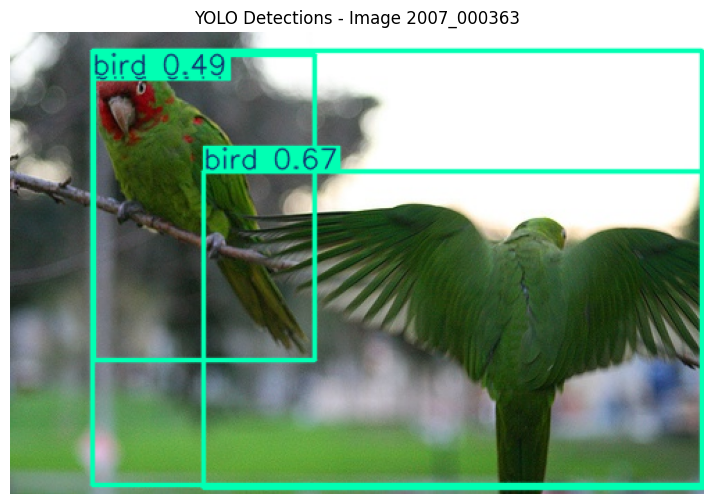

Saved: /content/figures/detection_clean_prediction_example.png


In [138]:
# Visualize YOLO detections on one clean sample image

annotated_image = detection_result.plot()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO Detections - Image {sample_image_id}")
plt.axis("off")

detection_example_path = (
    FIGURES_DIR /
    "detection_clean_prediction_example.png"
)

plt.savefig(
    detection_example_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", detection_example_path)

In [139]:
# Locate object-detection XML annotations directly by image ID

voc_root = DATA_DIR / "VOCdevkit" / "VOC2012"
annotations_dir = voc_root / "Annotations"

matched_annotation_paths = {}
missing_annotation_ids = []

for dataset_index in selected_indices:

    image_id = Path(
        dataset.images[dataset_index]
    ).stem

    annotation_path = (
        annotations_dir /
        f"{image_id}.xml"
    )

    if annotation_path.exists():
        matched_annotation_paths[dataset_index] = {
            "image_id": image_id,
            "annotation_path": annotation_path,
        }
    else:
        missing_annotation_ids.append(image_id)

print(f"Images with XML annotations: {len(matched_annotation_paths)}")
print(f"Images without XML annotations: {len(missing_annotation_ids)}")

if missing_annotation_ids:
    print("\nMissing image IDs:")
    print(missing_annotation_ids)
else:
    print("\nAll selected images have XML annotations.")

Images with XML annotations: 100
Images without XML annotations: 0

All selected images have XML annotations.


In [140]:
# Parse the ground-truth bounding boxes from one PASCAL VOC XML annotation

sample_index = selected_indices[0]
sample_image_id = Path(dataset.images[sample_index]).stem

sample_annotation_path = (
    annotations_dir /
    f"{sample_image_id}.xml"
)

tree = ET.parse(sample_annotation_path)
root = tree.getroot()

ground_truth_objects = []

for object_element in root.findall("object"):

    class_name = object_element.find("name").text

    bbox = object_element.find("bndbox")

    xmin = int(float(bbox.find("xmin").text))
    ymin = int(float(bbox.find("ymin").text))
    xmax = int(float(bbox.find("xmax").text))
    ymax = int(float(bbox.find("ymax").text))

    difficult = int(
        object_element.findtext("difficult", default="0")
    )

    truncated = int(
        object_element.findtext("truncated", default="0")
    )

    ground_truth_objects.append({
        "class_name": class_name,
        "bbox": [xmin, ymin, xmax, ymax],
        "difficult": difficult,
        "truncated": truncated,
    })

ground_truth_df = pd.DataFrame(ground_truth_objects)

print(f"Image ID: {sample_image_id}")
print(f"Number of ground-truth objects: {len(ground_truth_df)}")

display(ground_truth_df)

Image ID: 2007_000363
Number of ground-truth objects: 2


,class_name,bbox,difficult,truncated
0,bird,"[59, 15, 220, 239]",0,0
1,bird,"[161, 122, 500, 333]",0,1


In [141]:
# Map YOLO (COCO) class names to PASCAL VOC class names

VOC_DETECTION_CLASSES = {
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor"
}


YOLO_TO_VOC_CLASS_NAMES = {
    "airplane": "aeroplane",
    "motorcycle": "motorbike",
    "couch": "sofa",
    "tv": "tvmonitor",
    "potted plant": "pottedplant",
    "dining table": "diningtable"
}


def normalize_to_voc_class_name(class_name):
    """
    Convert a YOLO/COCO class name to the corresponding
    PASCAL VOC class name.
    """

    return YOLO_TO_VOC_CLASS_NAMES.get(
        class_name,
        class_name
    )

In [142]:
# Shared utilities for PASCAL VOC object-detection evaluation

def compute_box_iou(box_a, box_b):
    """
    Compute IoU between two boxes in continuous xyxy format:
    [xmin, ymin, xmax, ymax].
    """

    box_a = np.asarray(
        box_a,
        dtype=float
    )

    box_b = np.asarray(
        box_b,
        dtype=float
    )

    intersection_xmin = max(
        box_a[0],
        box_b[0]
    )

    intersection_ymin = max(
        box_a[1],
        box_b[1]
    )

    intersection_xmax = min(
        box_a[2],
        box_b[2]
    )

    intersection_ymax = min(
        box_a[3],
        box_b[3]
    )

    intersection_width = max(
        0.0,
        intersection_xmax -
        intersection_xmin
    )

    intersection_height = max(
        0.0,
        intersection_ymax -
        intersection_ymin
    )

    intersection_area = (
        intersection_width *
        intersection_height
    )

    area_a = (
        max(
            0.0,
            box_a[2] - box_a[0]
        )
        *
        max(
            0.0,
            box_a[3] - box_a[1]
        )
    )

    area_b = (
        max(
            0.0,
            box_b[2] - box_b[0]
        )
        *
        max(
            0.0,
            box_b[3] - box_b[1]
        )
    )

    union_area = (
        area_a +
        area_b -
        intersection_area
    )

    if union_area <= 0:
        return 0.0

    return (
        intersection_area /
        union_area
    )


def read_voc_detection_annotation(
    annotation_path
):
    """
    Read a PASCAL VOC XML annotation.

    Difficult objects are ignored.
    VOC 1-based coordinates are converted to the same
    continuous xyxy convention used by YOLO.
    """

    tree = ET.parse(
        annotation_path
    )

    root = tree.getroot()

    ground_truth_objects = []
    num_difficult_objects = 0

    for object_element in root.findall(
        "object"
    ):
        class_name = object_element.findtext(
            "name"
        )

        difficult = int(
            object_element.findtext(
                "difficult",
                default="0"
            )
        )

        if difficult == 1:
            num_difficult_objects += 1
            continue

        bbox_element = object_element.find(
            "bndbox"
        )

        xmin = float(
            bbox_element.findtext(
                "xmin"
            )
        )

        ymin = float(
            bbox_element.findtext(
                "ymin"
            )
        )

        xmax = float(
            bbox_element.findtext(
                "xmax"
            )
        )

        ymax = float(
            bbox_element.findtext(
                "ymax"
            )
        )

        ground_truth_objects.append({
            "class_name": class_name,
            "box": [
                xmin - 1.0,
                ymin - 1.0,
                xmax,
                ymax
            ]
        })

    return (
        ground_truth_objects,
        num_difficult_objects
    )


def extract_voc_predictions(
    detection_result
):
    """
    Convert YOLO predictions to PASCAL VOC class names
    and keep only classes that exist in PASCAL VOC.
    """

    predicted_objects = []

    if (
        detection_result.boxes is None
        or len(detection_result.boxes) == 0
    ):
        return predicted_objects

    predicted_boxes = (
        detection_result.boxes.xyxy
        .cpu()
        .numpy()
    )

    predicted_class_ids = (
        detection_result.boxes.cls
        .cpu()
        .numpy()
        .astype(int)
    )

    predicted_confidences = (
        detection_result.boxes.conf
        .cpu()
        .numpy()
    )

    for box, class_id, confidence in zip(
        predicted_boxes,
        predicted_class_ids,
        predicted_confidences
    ):
        yolo_class_name = (
            detection_result.names[
                class_id
            ]
        )

        voc_class_name = (
            normalize_to_voc_class_name(
                yolo_class_name
            )
        )

        if (
            voc_class_name
            not in VOC_DETECTION_CLASSES
        ):
            continue

        predicted_objects.append({
            "class_name": (
                voc_class_name
            ),
            "box": box.tolist(),
            "confidence": float(
                confidence
            )
        })

    return predicted_objects


def evaluate_voc_detections(
    ground_truth_objects,
    predicted_objects,
    iou_threshold=0.5
):
    """
    Perform class-aware greedy one-to-one matching.

    Returns:
    - overall counts and metrics
    - valid matches
    - per-class TP, FP, FN
    """

    candidate_matches = []

    for prediction_index, prediction in enumerate(
        predicted_objects
    ):
        for ground_truth_index, ground_truth in enumerate(
            ground_truth_objects
        ):
            if (
                prediction["class_name"]
                != ground_truth["class_name"]
            ):
                continue

            iou = compute_box_iou(
                prediction["box"],
                ground_truth["box"]
            )

            if iou >= iou_threshold:
                candidate_matches.append({
                    "prediction_index": (
                        prediction_index
                    ),
                    "ground_truth_index": (
                        ground_truth_index
                    ),
                    "class_name": (
                        prediction[
                            "class_name"
                        ]
                    ),
                    "iou": float(iou)
                })

    candidate_matches.sort(
        key=lambda match: match["iou"],
        reverse=True
    )

    matched_prediction_indices = set()
    matched_ground_truth_indices = set()
    valid_matches = []

    for match in candidate_matches:
        prediction_index = (
            match["prediction_index"]
        )

        ground_truth_index = (
            match["ground_truth_index"]
        )

        if (
            prediction_index
            in matched_prediction_indices
        ):
            continue

        if (
            ground_truth_index
            in matched_ground_truth_indices
        ):
            continue

        valid_matches.append(match)

        matched_prediction_indices.add(
            prediction_index
        )

        matched_ground_truth_indices.add(
            ground_truth_index
        )

    true_positives = len(
        valid_matches
    )

    false_positives = (
        len(predicted_objects) -
        true_positives
    )

    false_negatives = (
        len(ground_truth_objects) -
        true_positives
    )

    precision = (
        true_positives /
        (
            true_positives +
            false_positives
        )
        if (
            true_positives +
            false_positives
        ) > 0
        else 0.0
    )

    recall = (
        true_positives /
        (
            true_positives +
            false_negatives
        )
        if (
            true_positives +
            false_negatives
        ) > 0
        else 0.0
    )

    f1_score = (
        2.0 *
        precision *
        recall /
        (
            precision +
            recall
        )
        if (
            precision +
            recall
        ) > 0
        else 0.0
    )

    matched_iou_sum = float(
        sum(
            match["iou"]
            for match in valid_matches
        )
    )

    mean_matched_iou = (
        matched_iou_sum /
        true_positives
        if true_positives > 0
        else 0.0
    )

    per_class_rows = []

    classes_in_image = sorted(
        {
            obj["class_name"]
            for obj in ground_truth_objects
        }
        |
        {
            obj["class_name"]
            for obj in predicted_objects
        }
    )

    for class_name in classes_in_image:
        class_tp = sum(
            1
            for match in valid_matches
            if (
                match["class_name"]
                == class_name
            )
        )

        class_prediction_count = sum(
            1
            for prediction in predicted_objects
            if (
                prediction["class_name"]
                == class_name
            )
        )

        class_ground_truth_count = sum(
            1
            for ground_truth in ground_truth_objects
            if (
                ground_truth["class_name"]
                == class_name
            )
        )

        class_fp = (
            class_prediction_count -
            class_tp
        )

        class_fn = (
            class_ground_truth_count -
            class_tp
        )

        per_class_rows.append({
            "class_name": class_name,
            "true_positives": class_tp,
            "false_positives": class_fp,
            "false_negatives": class_fn,
            "num_predictions": (
                class_prediction_count
            ),
            "num_ground_truth_objects": (
                class_ground_truth_count
            )
        })

    overall_metrics = {
        "true_positives": (
            true_positives
        ),
        "false_positives": (
            false_positives
        ),
        "false_negatives": (
            false_negatives
        ),
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "matched_iou_sum": (
            matched_iou_sum
        ),
        "mean_matched_iou": (
            mean_matched_iou
        )
    }

    return (
        overall_metrics,
        valid_matches,
        per_class_rows
    )

In [143]:
# Evaluate YOLO predictions on one clean sample image

IOU_THRESHOLD = 0.5
YOLO_CONFIDENCE_THRESHOLD = 0.25

sample_annotation_path = (
    annotations_dir /
    f"{sample_image_id}.xml"
)

(
    sample_ground_truth_objects,
    sample_num_difficult_ignored
) = read_voc_detection_annotation(
    sample_annotation_path
)

sample_predicted_objects = (
    extract_voc_predictions(
        detection_result
    )
)

(
    sample_detection_metrics,
    sample_valid_matches,
    sample_per_class_rows
) = evaluate_voc_detections(
    ground_truth_objects=(
        sample_ground_truth_objects
    ),
    predicted_objects=(
        sample_predicted_objects
    ),
    iou_threshold=(
        IOU_THRESHOLD
    )
)


print(
    "Number of ground-truth objects:",
    len(sample_ground_truth_objects)
)

print(
    "Number of difficult objects ignored:",
    sample_num_difficult_ignored
)

print(
    "Number of VOC-compatible predictions:",
    len(sample_predicted_objects)
)

print(
    f"IoU threshold: {IOU_THRESHOLD}"
)

print(
    "True positives:",
    sample_detection_metrics[
        "true_positives"
    ]
)

print(
    "False positives:",
    sample_detection_metrics[
        "false_positives"
    ]
)

print(
    "False negatives:",
    sample_detection_metrics[
        "false_negatives"
    ]
)

print(
    "Precision:",
    f"{sample_detection_metrics['precision']:.3f}"
)

print(
    "Recall:",
    f"{sample_detection_metrics['recall']:.3f}"
)

print(
    "F1 score:",
    f"{sample_detection_metrics['f1_score']:.3f}"
)

print(
    "Mean matched IoU:",
    f"{sample_detection_metrics['mean_matched_iou']:.3f}"
)

print("\nValid matches:")
display(
    pd.DataFrame(
        sample_valid_matches
    )
)

print("\nPer-class results:")
display(
    pd.DataFrame(
        sample_per_class_rows
    )
)

Number of ground-truth objects: 2
Number of difficult objects ignored: 0
Number of VOC-compatible predictions: 3
IoU threshold: 0.5
True positives: 2
False positives: 1
False negatives: 0
Precision: 0.667
Recall: 1.000
F1 score: 0.800
Mean matched IoU: 0.902

Valid matches:


,prediction_index,ground_truth_index,class_name,iou
0,2,0,bird,0.962632
1,0,1,bird,0.842062



Per-class results:


,class_name,true_positives,false_positives,false_negatives,num_predictions,num_ground_truth_objects
0,bird,2,1,0,3,2


In [144]:
# Evaluate YOLO object detection on all clean images

detection_clean_results = []
detection_clean_per_class_results = []

for position, dataset_index in enumerate(
    selected_indices,
    start=1
):
    image, _ = dataset[
        dataset_index
    ]

    image_id = Path(
        dataset.images[
            dataset_index
        ]
    ).stem

    annotation_path = (
        annotations_dir /
        f"{image_id}.xml"
    )

    if not annotation_path.exists():
        raise FileNotFoundError(
            f"Annotation file not found: "
            f"{annotation_path}"
        )

    # Read PASCAL VOC ground truth
    (
        ground_truth_objects,
        num_difficult_objects
    ) = read_voc_detection_annotation(
        annotation_path
    )

    # Run YOLO
    detection_result = (
        detection_model.predict(
            source=image,
            conf=(
                YOLO_CONFIDENCE_THRESHOLD
            ),
            verbose=False
        )[0]
    )

    predicted_objects = (
        extract_voc_predictions(
            detection_result
        )
    )

    (
        overall_metrics,
        valid_matches,
        per_class_rows
    ) = evaluate_voc_detections(
        ground_truth_objects=(
            ground_truth_objects
        ),
        predicted_objects=(
            predicted_objects
        ),
        iou_threshold=(
            IOU_THRESHOLD
        )
    )

    prediction_confidences = [
        prediction["confidence"]
        for prediction in predicted_objects
    ]

    mean_prediction_confidence = (
        float(
            np.mean(
                prediction_confidences
            )
        )
        if prediction_confidences
        else 0.0
    )

    detection_clean_results.append({
        "dataset_index": (
            dataset_index
        ),
        "image_id": image_id,
        "num_ground_truth_objects": (
            len(ground_truth_objects)
        ),
        "num_difficult_objects_ignored": (
            num_difficult_objects
        ),
        "num_predictions": (
            len(predicted_objects)
        ),
        **overall_metrics,
        "mean_prediction_confidence": (
            mean_prediction_confidence
        ),
        "confidence_threshold": (
            YOLO_CONFIDENCE_THRESHOLD
        ),
        "iou_threshold": (
            IOU_THRESHOLD
        )
    })

    for class_row in per_class_rows:
        detection_clean_per_class_results.append({
            "dataset_index": (
                dataset_index
            ),
            "image_id": (
                image_id
            ),
            **class_row
        })

    if (
        position % 10 == 0
        or position == len(
            selected_indices
        )
    ):
        print(
            f"Processed {position}/"
            f"{len(selected_indices)} images"
        )


detection_clean_df = pd.DataFrame(
    detection_clean_results
)

detection_clean_per_class_df = pd.DataFrame(
    detection_clean_per_class_results
)


print(
    "Finished evaluating object detection "
    "on all clean images"
)

display(
    detection_clean_df.head()
)

display(
    detection_clean_per_class_df.head()
)

Processed 10/100 images
Processed 20/100 images
Processed 30/100 images
Processed 40/100 images
Processed 50/100 images
Processed 60/100 images
Processed 70/100 images
Processed 80/100 images
Processed 90/100 images
Processed 100/100 images
Finished evaluating object detection on all clean images


,dataset_index,image_id,num_ground_truth_objects,num_difficult_objects_ignored,num_predictions,true_positives,false_positives,false_negatives,precision,recall,f1_score,matched_iou_sum,mean_matched_iou,mean_prediction_confidence,confidence_threshold,iou_threshold
0,11,2007_000363,2,0,3,2,1,0,0.666667,1.0,0.800000,1.804695,0.902347,0.523176,0.25,0.5
1,31,2007_000904,2,1,4,1,3,1,0.250000,0.5,0.333333,0.803142,0.803142,0.522479,0.25,0.5
2,88,2007_002895,2,0,3,2,1,0,0.666667,1.0,0.800000,1.505669,0.752835,0.480741,0.25,0.5
3,99,2007_003191,1,0,1,1,0,0,1.000000,1.0,1.000000,0.978010,0.978010,0.920895,0.25,0.5
4,127,2007_004166,2,6,8,1,7,1,0.125000,0.5,0.200000,0.819482,0.819482,0.664444,0.25,0.5


,dataset_index,image_id,class_name,true_positives,false_positives,false_negatives,num_predictions,num_ground_truth_objects
0,11,2007_000363,bird,2,1,0,3,2
1,31,2007_000904,cow,1,2,0,3,1
2,31,2007_000904,horse,0,1,0,1,0
3,31,2007_000904,person,0,0,1,0,1
4,88,2007_002895,person,2,1,0,3,2


In [145]:
# Summarize YOLO object-detection performance on clean images

# ---------------------------------------------------------
# Overall totals
# ---------------------------------------------------------

total_true_positives = int(
    detection_clean_df[
        "true_positives"
    ].sum()
)

total_false_positives = int(
    detection_clean_df[
        "false_positives"
    ].sum()
)

total_false_negatives = int(
    detection_clean_df[
        "false_negatives"
    ].sum()
)

total_predictions = int(
    detection_clean_df[
        "num_predictions"
    ].sum()
)

total_ground_truth_objects = int(
    detection_clean_df[
        "num_ground_truth_objects"
    ].sum()
)

total_difficult_objects_ignored = int(
    detection_clean_df[
        "num_difficult_objects_ignored"
    ].sum()
)


global_precision = (
    total_true_positives /
    (
        total_true_positives +
        total_false_positives
    )
    if (
        total_true_positives +
        total_false_positives
    ) > 0
    else 0.0
)

global_recall = (
    total_true_positives /
    (
        total_true_positives +
        total_false_negatives
    )
    if (
        total_true_positives +
        total_false_negatives
    ) > 0
    else 0.0
)

global_f1 = (
    2.0 *
    global_precision *
    global_recall /
    (
        global_precision +
        global_recall
    )
    if (
        global_precision +
        global_recall
    ) > 0
    else 0.0
)

total_matched_iou = float(
    detection_clean_df[
        "matched_iou_sum"
    ].sum()
)

global_mean_matched_iou = (
    total_matched_iou /
    total_true_positives
    if total_true_positives > 0
    else 0.0
)


detection_clean_summary = pd.DataFrame([
    {
        "num_images": (
            len(detection_clean_df)
        ),
        "total_ground_truth_objects": (
            total_ground_truth_objects
        ),
        "total_difficult_objects_ignored": (
            total_difficult_objects_ignored
        ),
        "total_predictions": (
            total_predictions
        ),
        "total_true_positives": (
            total_true_positives
        ),
        "total_false_positives": (
            total_false_positives
        ),
        "total_false_negatives": (
            total_false_negatives
        ),
        "mean_per_image_precision": float(
            detection_clean_df[
                "precision"
            ].mean()
        ),
        "mean_per_image_recall": float(
            detection_clean_df[
                "recall"
            ].mean()
        ),
        "mean_per_image_f1": float(
            detection_clean_df[
                "f1_score"
            ].mean()
        ),
        "global_precision": (
            global_precision
        ),
        "global_recall": (
            global_recall
        ),
        "global_f1": (
            global_f1
        ),
        "global_mean_matched_iou": (
            global_mean_matched_iou
        ),
        "confidence_threshold": (
            YOLO_CONFIDENCE_THRESHOLD
        ),
        "iou_threshold": (
            IOU_THRESHOLD
        )
    }
])


# ---------------------------------------------------------
# Per-class totals
# ---------------------------------------------------------

detection_clean_per_class_summary = (
    detection_clean_per_class_df
    .groupby(
        "class_name",
        as_index=False
    )
    .agg(
        total_true_positives=(
            "true_positives",
            "sum"
        ),
        total_false_positives=(
            "false_positives",
            "sum"
        ),
        total_false_negatives=(
            "false_negatives",
            "sum"
        ),
        total_predictions=(
            "num_predictions",
            "sum"
        ),
        total_ground_truth_objects=(
            "num_ground_truth_objects",
            "sum"
        )
    )
)


detection_clean_per_class_summary[
    "precision"
] = np.divide(
    detection_clean_per_class_summary[
        "total_true_positives"
    ],
    (
        detection_clean_per_class_summary[
            "total_true_positives"
        ]
        +
        detection_clean_per_class_summary[
            "total_false_positives"
        ]
    ),
    out=np.zeros(
        len(
            detection_clean_per_class_summary
        ),
        dtype=float
    ),
    where=(
        detection_clean_per_class_summary[
            "total_true_positives"
        ]
        +
        detection_clean_per_class_summary[
            "total_false_positives"
        ]
    ) > 0
)

detection_clean_per_class_summary[
    "recall"
] = np.divide(
    detection_clean_per_class_summary[
        "total_true_positives"
    ],
    (
        detection_clean_per_class_summary[
            "total_true_positives"
        ]
        +
        detection_clean_per_class_summary[
            "total_false_negatives"
        ]
    ),
    out=np.zeros(
        len(
            detection_clean_per_class_summary
        ),
        dtype=float
    ),
    where=(
        detection_clean_per_class_summary[
            "total_true_positives"
        ]
        +
        detection_clean_per_class_summary[
            "total_false_negatives"
        ]
    ) > 0
)

detection_clean_per_class_summary[
    "f1_score"
] = np.divide(
    2.0
    *
    detection_clean_per_class_summary[
        "precision"
    ]
    *
    detection_clean_per_class_summary[
        "recall"
    ],
    (
        detection_clean_per_class_summary[
            "precision"
        ]
        +
        detection_clean_per_class_summary[
            "recall"
        ]
    ),
    out=np.zeros(
        len(
            detection_clean_per_class_summary
        ),
        dtype=float
    ),
    where=(
        detection_clean_per_class_summary[
            "precision"
        ]
        +
        detection_clean_per_class_summary[
            "recall"
        ]
    ) > 0
)

detection_clean_per_class_summary = (
    detection_clean_per_class_summary
    .sort_values(
        "class_name"
    )
    .reset_index(
        drop=True
    )
)


print("Global object-detection summary:")
display(
    detection_clean_summary
)

print("\nPer-class object-detection summary:")
display(
    detection_clean_per_class_summary
)

Global object-detection summary:


,num_images,total_ground_truth_objects,total_difficult_objects_ignored,total_predictions,total_true_positives,total_false_positives,total_false_negatives,mean_per_image_precision,mean_per_image_recall,mean_per_image_f1,global_precision,global_recall,global_f1,global_mean_matched_iou,confidence_threshold,iou_threshold
0,100,245,47,304,198,106,47,0.783643,0.882452,0.803322,0.651316,0.808163,0.721311,0.871162,0.25,0.5



Per-class object-detection summary:


,class_name,total_true_positives,total_false_positives,total_false_negatives,total_predictions,total_ground_truth_objects,precision,recall,f1_score
0,aeroplane,8,2,1,10,9,0.800000,0.888889,0.842105
1,bicycle,4,0,0,4,4,1.000000,1.000000,1.000000
2,bird,9,1,2,10,11,0.900000,0.818182,0.857143
3,boat,13,18,4,31,17,0.419355,0.764706,0.541667
4,bottle,7,2,4,9,11,0.777778,0.636364,0.700000
5,bus,12,3,5,15,17,0.800000,0.705882,0.750000
6,car,14,9,4,23,18,0.608696,0.777778,0.682927
7,cat,8,3,0,11,8,0.727273,1.000000,0.842105
8,chair,13,15,8,28,21,0.464286,0.619048,0.530612
9,cow,7,3,0,10,7,0.700000,1.000000,0.823529


In [146]:
# Save YOLO clean-image baseline results

detection_results_path = (
    RESULTS_DIR /
    "detection_clean_baseline.csv"
)

detection_summary_path = (
    RESULTS_DIR /
    "detection_clean_summary.csv"
)

detection_per_class_detailed_path = (
    RESULTS_DIR /
    "detection_clean_per_class_detailed.csv"
)

detection_per_class_summary_path = (
    RESULTS_DIR /
    "detection_clean_per_class_summary.csv"
)


detection_clean_df.to_csv(
    detection_results_path,
    index=False
)

detection_clean_summary.to_csv(
    detection_summary_path,
    index=False
)

detection_clean_per_class_df.to_csv(
    detection_per_class_detailed_path,
    index=False
)

detection_clean_per_class_summary.to_csv(
    detection_per_class_summary_path,
    index=False
)


print("Object-detection baseline results saved:")

print(
    "-",
    detection_results_path
)

print(
    "-",
    detection_summary_path
)

print(
    "-",
    detection_per_class_detailed_path
)

print(
    "-",
    detection_per_class_summary_path
)

Object-detection baseline results saved:
- /content/results/detection_clean_baseline.csv
- /content/results/detection_clean_summary.csv
- /content/results/detection_clean_per_class_detailed.csv
- /content/results/detection_clean_per_class_summary.csv
